# Data Audit — 웰니스 앱 리텐션 공모전

**목적:** 원천 CSV 두 개의 품질을 검증한다. 지표 계산·정제는 이 노트북에서 하지 않는다.  
**산출물:** `reports/data_audit.md`  
**작성일:** 2026-06-29

---

## 점검 항목
1. 파일 기본 정보 (행·열 수, 인코딩)
2. 컬럼별 결측치 현황
3. 중복 행 / PK 중복
4. 날짜 파싱 성공 여부 & 범위
5. 시간적 정합성 (이벤트 < 가입일 여부)
6. 조인 키 무결성 (User_ID 참조 완전성)
7. 카테고리 컬럼 도메인 값
8. 논리 정합성 (알림_유형 ↔ Event_Type)
9. Session_ID 결측 패턴
10. User별 이벤트 수 분포 (편향 탐색)
11. 이벤트 없는 유저 프로파일링

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('font', family='AppleGothic')  # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

RAW = '../data/raw'

profile = pd.read_csv(f'{RAW}/User_Profile.csv', encoding='utf-8-sig')
events  = pd.read_csv(f'{RAW}/Event_Log.csv',   encoding='utf-8-sig')

print('Profile shape :', profile.shape)
print('Event   shape :', events.shape)

Profile shape : (12500, 6)
Event   shape : (1757262, 5)


In [38]:
profile_df = pd.read_csv('../data/첨부파일 01_User_Profile.csv', encoding='utf-8')
event_log_df = pd.read_csv('../data/첨부파일 02_Event_Log.csv', encoding='utf-8')
print(profile_df.shape)
print(event_log_df.shape)

(12500, 6)
(1757262, 5)


## 1. 파일 기본 정보

In [19]:
print('=== User_Profile columns & dtypes ===')
print(profile.dtypes)
print()
print('=== Event_Log columns & dtypes ===')
print(events.dtypes)

=== User_Profile columns & dtypes ===
User_ID           str
가입일자              str
가입경로              str
기기                str
알림수신동의여부       object
알림수신동의_변경일자       str
dtype: object

=== Event_Log columns & dtypes ===
User_ID       str
Event_Time    str
Event_Type    str
Session_ID    str
알림_유형         str
dtype: object


In [21]:
profile.describe()

,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자
count,12500,12500,12363,12379,12384,1976
unique,12500,146,2,2,2,148
top,U0000001,2025-02-15,퍼포먼스광고,iOS,True,2025-05-29
freq,1,173,6852,7175,7984,32


In [22]:
profile.head(3)

,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자
0,U0000001,2025-01-25,오가닉,iOS,True,NaN
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24
2,U0000003,2025-05-14,오가닉,iOS,False,NaN


In [23]:
events.head(3)

,User_ID,Event_Time,Event_Type,Session_ID,알림_유형
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN


## 2. 결측치 현황

In [24]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(2)
    return pd.DataFrame({'결측 수': miss, '결측률(%)': pct, '비고': ''}, index=df.columns).rename_axis(f'{name} 컬럼')

print('--- User_Profile ---')
display(missing_summary(profile, 'User_Profile'))
print('--- Event_Log ---')
display(missing_summary(events, 'Event_Log'))

--- User_Profile ---


,결측 수,결측률(%),비고
User_Profile 컬럼,,,
User_ID,0,0.00,
가입일자,0,0.00,
가입경로,137,1.10,
기기,121,0.97,
알림수신동의여부,116,0.93,
알림수신동의_변경일자,10524,84.19,


--- Event_Log ---


,결측 수,결측률(%),비고
Event_Log 컬럼,,,
User_ID,0,0.00,
Event_Time,0,0.00,
Event_Type,26456,1.51,
Session_ID,241502,13.74,
알림_유형,1538380,87.54,


## 3. 중복 행 / PK 중복

In [25]:
print('[User_Profile]')
print(f'  완전 중복 행       : {profile.duplicated().sum()}')
print(f'  User_ID 중복      : {profile.duplicated("User_ID").sum()}')

print('[Event_Log]')
print(f'  완전 중복 행       : {events.duplicated().sum()}')
dup_key = ['User_ID','Event_Time','Event_Type']
n_dup = events.duplicated(dup_key).sum()
print(f'  복합키(User+Time+Type) 중복: {n_dup}')
if n_dup > 0:
    display(events[events.duplicated(dup_key, keep=False)].sort_values(dup_key).head(10))

[User_Profile]
  완전 중복 행       : 0
  User_ID 중복      : 0
[Event_Log]
  완전 중복 행       : 0
  복합키(User+Time+Type) 중복: 11


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형
83256,U0000620,2025-01-06 22:38:15,앱실행,cae7af38e6,NaN
83257,U0000620,2025-01-06 22:38:15,앱실행,cef2269d29,NaN
137380,U0000994,2025-04-27 13:23:01,앱실행,11984d7402,NaN
137381,U0000994,2025-04-27 13:23:01,앱실행,c72c942974,NaN
137382,U0000994,2025-04-27 13:23:31,운동기록,11984d7402,NaN
137383,U0000994,2025-04-27 13:23:31,운동기록,c72c942974,NaN
363544,U0002637,2025-03-25 14:26:10,챌린지참여,4280b7c00e,NaN
363545,U0002637,2025-03-25 14:26:10,챌린지참여,f1641d5f16,NaN
589788,U0004303,2025-02-20 17:44:46,운동기록,13b29fbe95,NaN
589789,U0004303,2025-02-20 17:44:46,운동기록,7e764cde94,NaN


## 4. 날짜 파싱 & 범위

In [26]:
profile['가입일자_dt']  = pd.to_datetime(profile['가입일자'],  errors='coerce')
profile['변경일자_dt']  = pd.to_datetime(profile['알림수신동의_변경일자'], errors='coerce')
events['Event_Time_dt'] = pd.to_datetime(events['Event_Time'], errors='coerce')

print('[가입일자] 파싱 실패:', profile['가입일자_dt'].isnull().sum())
print('  범위:', profile['가입일자_dt'].min().date(), '~', profile['가입일자_dt'].max().date())

print('[Event_Time] 파싱 실패:', events['Event_Time_dt'].isnull().sum())
print('  범위:', events['Event_Time_dt'].min(), '~', events['Event_Time_dt'].max())

[가입일자] 파싱 실패: 0
  범위: 2025-01-01 ~ 2025-05-26
[Event_Time] 파싱 실패: 0
  범위: 2025-01-01 07:00:07 ~ 2025-06-30 22:59:51


## 5. 시간적 정합성 — 가입 전 이벤트

In [27]:
merged = events.merge(profile[['User_ID','가입일자_dt']], on='User_ID', how='left')
before_signup = merged[merged['Event_Time_dt'] < merged['가입일자_dt']]
print(f'가입일 이전 이벤트: {len(before_signup)} 건')
if len(before_signup) > 0:
    display(before_signup.head())

가입일 이전 이벤트: 0 건


## 6. 조인 키 무결성

In [28]:
p_ids = set(profile['User_ID'])
e_ids = set(events['User_ID'])

only_event   = e_ids - p_ids   # 고아 이벤트
only_profile = p_ids - e_ids   # 이벤트 없는 유저

print(f'Profile unique users : {len(p_ids):,}')
print(f'Event   unique users : {len(e_ids):,}')
print(f'고아 이벤트 (Event에만 존재) : {len(only_event)}')
print(f'이벤트 없는 유저              : {len(only_profile)}')

Profile unique users : 12,500
Event   unique users : 12,453
고아 이벤트 (Event에만 존재) : 0
이벤트 없는 유저              : 47


## 7. 카테고리 컬럼 도메인

In [29]:
for col in ['가입경로','기기','알림수신동의여부']:
    print(f'[{col}]')
    print(profile[col].value_counts(dropna=False))
    print()

[가입경로]
가입경로
퍼포먼스광고    6852
오가닉       5511
NaN        137
Name: count, dtype: int64

[기기]
기기
iOS        7175
Android    5204
NaN         121
Name: count, dtype: int64

[알림수신동의여부]
알림수신동의여부
True     7984
False    4400
NaN       116
Name: count, dtype: int64



In [30]:
print('[Event_Type]')
print(events['Event_Type'].value_counts(dropna=False))
print()
print('[알림_유형]')
print(events['알림_유형'].value_counts(dropna=False))

[Event_Type]
Event_Type
앱실행       728657
수면기록      242978
알림수신      194324
운동기록      131269
마음챙김      130344
식단기록      101366
챌린지참여      96829
챌린지_탐색     78101
NaN        26456
알림오픈       21219
온보딩_완료      5719
Name: count, dtype: int64

[알림_유형]
알림_유형
NaN       1538380
리마인드        85830
광고성         78262
챌린지_알림      54790
Name: count, dtype: int64


## 8. 논리 정합성 — 알림_유형 ↔ Event_Type

In [31]:
NOTIF_EVENTS = {'알림수신', '알림오픈'}

# 알림 이벤트인데 알림_유형 결측
notif_rows = events[events['Event_Type'].isin(NOTIF_EVENTS)]
print(f'알림수신+알림오픈 행 수 : {len(notif_rows):,}')
print(f'  → 알림_유형 결측    : {notif_rows["알림_유형"].isnull().sum()}')

# 알림 이벤트 아닌데 알림_유형 채워짐
non_notif_filled = events[~events['Event_Type'].isin(NOTIF_EVENTS) & events['알림_유형'].notna()]
print(f'\n비알림 이벤트이나 알림_유형 채워진 행: {len(non_notif_filled):,}')
if len(non_notif_filled) > 0:
    print(non_notif_filled['Event_Type'].value_counts())
    display(non_notif_filled.head())

알림수신+알림오픈 행 수 : 215,543
  → 알림_유형 결측    : 0

비알림 이벤트이나 알림_유형 채워진 행: 3,339
Series([], Name: count, dtype: int64)


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형,Event_Time_dt
1833,U0000011,2025-03-01 20:32:00,NaN,NaN,리마인드,2025-03-01 20:32:00
3554,U0000023,2025-05-03 17:58:00,NaN,NaN,리마인드,2025-05-03 17:58:00
4381,U0000028,2025-04-22 17:29:00,NaN,NaN,광고성,2025-04-22 17:29:00
4639,U0000032,2025-05-30 13:27:00,NaN,NaN,챌린지_알림,2025-05-30 13:27:00
5128,U0000034,2025-06-12 09:01:00,NaN,NaN,광고성,2025-06-12 09:01:00


## 9. Session_ID 결측 패턴

In [32]:
total_miss_sess = events['Session_ID'].isnull().sum()
print(f'Session_ID 전체 결측: {total_miss_sess:,} ({total_miss_sess/len(events)*100:.1f}%)')
print()
print('Event_Type별 Session_ID 결측 수')
print(events[events['Session_ID'].isnull()]['Event_Type'].value_counts(dropna=False))

Session_ID 전체 결측: 241,502 (13.7%)

Event_Type별 Session_ID 결측 수
Event_Type
알림수신      194324
알림오픈       21219
앱실행        10610
NaN         3676
수면기록        3541
운동기록        1965
마음챙김        1914
식단기록        1533
챌린지참여       1454
챌린지_탐색      1191
온보딩_완료        75
Name: count, dtype: int64


## 10. User별 이벤트 수 분포

count    12453.000000
mean       141.111539
std        172.167588
min          1.000000
1%           3.000000
5%           6.000000
25%         20.000000
50%         51.000000
75%        219.000000
95%        522.000000
99%        592.480000
max        697.000000
dtype: float64

이벤트 1건 이하 유저: 17


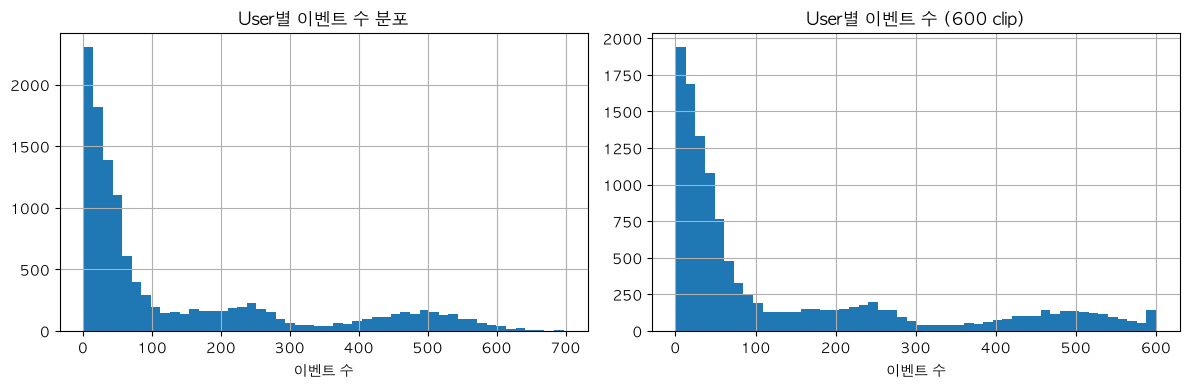

In [33]:
user_cnt = events.groupby('User_ID').size()
print(user_cnt.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]))
print(f'\n이벤트 1건 이하 유저: {(user_cnt <= 1).sum()}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
user_cnt.hist(bins=50, ax=ax1)
ax1.set_title('User별 이벤트 수 분포')
ax1.set_xlabel('이벤트 수')
user_cnt.clip(upper=600).hist(bins=50, ax=ax2)
ax2.set_title('User별 이벤트 수 (600 clip)')
ax2.set_xlabel('이벤트 수')
plt.tight_layout()
plt.savefig('../reports/user_event_dist.png', dpi=120)
plt.show()

## 11. 이벤트 없는 유저 프로파일링

In [34]:
no_event_ids  = p_ids - e_ids
no_event_df   = profile[profile['User_ID'].isin(no_event_ids)]
print(f'이벤트 없는 유저 수: {len(no_event_df)}')
print(f'가입일 범위: {no_event_df["가입일자_dt"].min().date()} ~ {no_event_df["가입일자_dt"].max().date()}')
print()
print('가입경로 분포:')
print(no_event_df['가입경로'].value_counts(dropna=False))
print()
print('기기 분포:')
print(no_event_df['기기'].value_counts(dropna=False))

이벤트 없는 유저 수: 47
가입일 범위: 2025-03-10 ~ 2025-03-14

가입경로 분포:
가입경로
퍼포먼스광고    29
오가닉       17
NaN        1
Name: count, dtype: int64

기기 분포:
기기
iOS        27
Android    19
NaN         1
Name: count, dtype: int64


---
## 종합 요약

결과는 `reports/data_audit.md` 참조.